# Nutricion de Alimentos Estadisticas Descriptivas y Analisis de Correlacion

Dataset: `FOOD-DATA-GROUP1.csv` 551 alimentos descritos por 34 variables nutricionales.

Contenido del analisis (fase de *Data Understanding* de CRISP-DM):

1. Tipos de datos, cantidad de campos y registros, y calidad de los datos.
2. Estadisticas descriptivas de cada variable (media, moda, desviacion estandar, minimo, maximo, etc.).
3. Correlacion de cada componente con `Caloric Value` y con `Nutrition Density`.
4. Descripcion de cinco columnas representativas.
5. Propuesta de un problema de Machine Learning en el contexto del dataset, argumentando que columnas se usarian como entrada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

# Colores fijos reutilizados en todas las figuras para que signifiquen lo mismo.
POS, NEG, NEUTRAL = "#b2182b", "#2166ac", "#8a8a8a"

In [2]:
df = pd.read_csv("FOOD-DATA-GROUP1.csv")

# Dos columnas sobrantes de la exportacion: ambas son solo el numero de fila.
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

# 'nutrients' = todas las columnas numericas (todo menos el nombre del alimento).
nutrients = df.columns.drop("food")
df.head()

,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,cream cheese,51,5.000,2.900,1.300,0.200,0.800,0.500,0.900,0.000,14.600,0.016,7.600,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.500,19.100,0.039,7.070
1,neufchatel cheese,215,19.400,10.900,4.900,0.800,3.100,2.700,7.800,0.000,62.900,0.300,53.600,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.200,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.600,2.300,0.900,0.000,0.900,3.400,0.800,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.400
3,ricotta cheese,30,2.000,1.300,0.500,0.002,1.500,0.091,1.500,0.000,9.800,0.017,14.700,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.800,43.800,0.035,5.196
4,cream cheese low fat,30,2.300,1.400,0.600,0.042,1.200,0.900,1.200,0.000,8.100,0.046,10.000,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.100,0.034,0.053,27.007


## 1. Tipos de datos, campos, registros y calidad

Primer vistazo a la estructura del dataset: cuantos campos (columnas) y registros (filas) hay, de que tipo es cada columna, y si existen valores faltantes o duplicados.

In [3]:
# select_dtypes detecta bien las columnas de texto (la comparacion dtype == object
# fallaba porque en esta version de pandas 'food' se lee como 'str', no 'object').
no_numericas = df.select_dtypes(exclude="number").columns.tolist()

print(f"registros (filas):        {df.shape[0]}")
print(f"campos (columnas):        {df.shape[1]}")
print(f"  - numericas:            {df.select_dtypes(include='number').shape[1]}")
print(f"  - de texto/categoricas: {len(no_numericas)}  -> {no_numericas}")
print(f"valores faltantes:        {int(df.isna().sum().sum())}")
print(f"nombres de alimento dup.: {int(df['food'].duplicated().sum())}")
print("\nDesglose de tipos de dato:")
print(df.dtypes.value_counts())

registros (filas):        551
campos (columnas):        35
  - numericas:            34
  - de texto/categoricas: 1  -> ['food']
valores faltantes:        0
nombres de alimento dup.: 0

Desglose de tipos de dato:
float64    33
str         1
int64       1
Name: count, dtype: int64


## 2. Estadisticas descriptivas

`describe()` mas las medidas que importan para datos nutricionales sesgados: la **moda**
(valor mas frecuente), la **mediana** (robusta frente a la cola derecha larga), el rango
intercuartil (`IQR`), el coeficiente de variacion (`CV`, dispersion relativa a la media
comparable entre variables con unidades muy distintas), la asimetria (`skew`), la curtosis
(`kurtosis`) y el porcentaje de ceros exactos (muchos micronutrientes estan ausentes en la
mayoria de los alimentos).

In [4]:
stats = df[nutrients].describe().T
stats["moda"] = df[nutrients].mode().iloc[0]     # valor mas frecuente de cada variable
stats["mediana"] = df[nutrients].median()
stats["IQR"] = stats["75%"] - stats["25%"]
stats["CV"] = stats["std"] / stats["mean"]
stats["skew"] = df[nutrients].skew()
stats["kurtosis"] = df[nutrients].kurtosis()
stats["ceros %"] = (df[nutrients] == 0).mean() * 100

stats[["count", "mean", "moda", "std", "min", "25%", "mediana", "75%", "max",
       "IQR", "CV", "skew", "kurtosis", "ceros %"]]

,count,mean,moda,std,min,25%,mediana,75%,max,IQR,CV,skew,kurtosis,ceros %
Caloric Value,551.000,237.359,186.000,199.236,3.000,94.500,186.000,337.000,"1,578.000",242.500,0.839,1.928,6.834,0.000
Fat,551.000,10.767,0.200,12.544,0.000,2.500,6.600,14.400,87.500,11.900,1.165,2.323,7.106,0.726
Saturated Fats,551.000,3.723,0.200,5.397,0.000,0.500,1.800,4.800,43.500,4.300,1.450,3.438,17.140,3.085
Monounsaturated Fats,551.000,4.002,0.000,5.541,0.000,0.600,2.200,5.150,48.000,4.550,1.385,3.217,14.812,3.448
Polyunsaturated Fats,551.000,2.171,0.300,3.471,0.000,0.400,1.100,2.600,40.100,2.200,1.599,5.283,44.887,4.174
Carbohydrates,551.000,15.819,0.000,20.289,0.000,0.000,5.100,28.700,128.300,28.700,1.283,1.634,3.742,30.309
Sugars,551.000,2.709,0.000,7.456,0.000,0.000,0.000,2.200,70.800,2.200,2.752,5.543,36.741,56.624
Protein,551.000,18.418,4.600,18.932,0.000,5.300,11.900,25.650,86.900,20.350,1.028,1.726,2.695,1.452
Dietary Fiber,551.000,1.098,0.000,2.157,0.000,0.000,0.000,1.500,17.500,1.500,1.964,3.125,13.233,60.436
Cholesterol,551.000,61.591,0.000,70.143,0.000,9.750,33.900,82.650,352.500,72.900,1.139,1.527,1.795,11.978


**Conclusiones de las estadisticas:**

- **La media es mayor que la mediana en casi todas las variables** (por ejemplo `Caloric Value`: media 237 vs mediana 186). Esto confirma la fuerte asimetria positiva (`skew` > 0), unos pocos alimentos muy concentrados empujan el promedio hacia arriba, asi que la mediana describe mejor al alimento "tipico".
- **La moda es poco informativa en este dataset.** En 18 de las 34 variables numericas la moda es `0.0`; no porque cero sea un valor "representativo", sino porque son nutrientes ausentes en muchos alimentos. En variables continuas y dispersas como estas, la moda aporta poco frente a la media y la mediana.
- **Las escalas son muy dispares** (de decimas en vitaminas a miles en `Potassium`). Cualquier metodo basado en distancias necesitara estandarizar las variables antes de usarlas.

Distribucion de la variable `Caloric Value`:

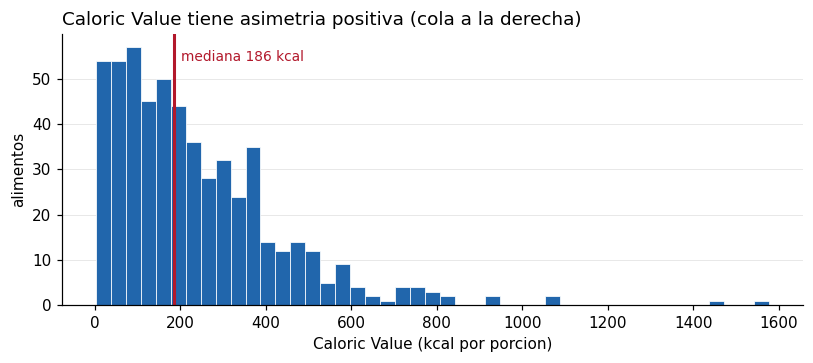

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(df["Caloric Value"], bins=45, color=NEG, edgecolor="white", linewidth=0.5)
ax.axvline(df["Caloric Value"].median(), color=POS, lw=2)
ax.text(df["Caloric Value"].median() + 15, ax.get_ylim()[1] * 0.9,
        f"mediana {df['Caloric Value'].median():.0f} kcal", color=POS, fontsize=9)
ax.set_xlabel("Caloric Value (kcal por porcion)")
ax.set_ylabel("alimentos")
ax.set_title("Caloric Value tiene asimetria positiva (cola a la derecha)", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout()

## 3. Correlacion de cada componente con `Caloric Value`

Correlacion de Pearson (`r`) entre `Caloric Value` y cada una de las demas variables, ordenada.

In [6]:
corr_matrix = df[nutrients].corr()
cal_corr = corr_matrix["Caloric Value"].drop("Caloric Value").sort_values(ascending=False)
cal_corr.to_frame("r vs Caloric Value")

,r vs Caloric Value
Fat,0.909
Polyunsaturated Fats,0.759
Monounsaturated Fats,0.704
Saturated Fats,0.665
Carbohydrates,0.625
Protein,0.599
Phosphorus,0.549
Nutrition Density,0.543
Cholesterol,0.537
Potassium,0.524


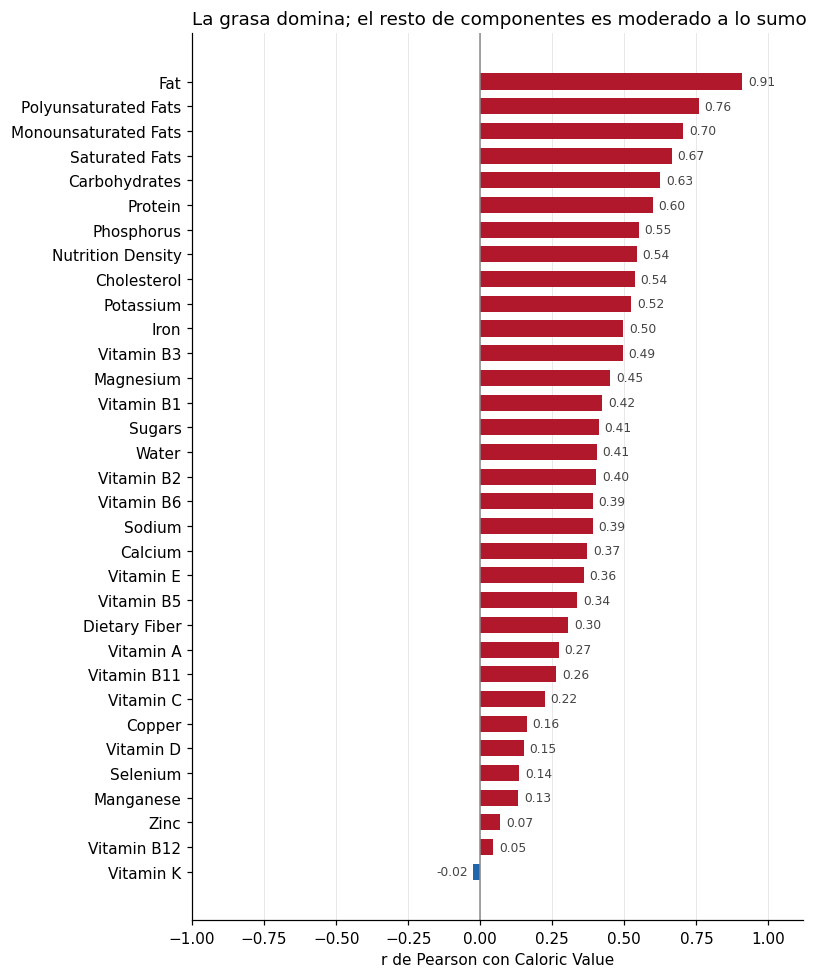

In [7]:
order = cal_corr.sort_values()

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.barh(order.index, order.values, color=[POS if v >= 0 else NEG for v in order], height=0.65)
ax.axvline(0, color=NEUTRAL, lw=1)
ax.set_xlim(-1, 1.12)
ax.set_xlabel("r de Pearson con Caloric Value")
ax.set_title("La grasa domina; el resto de componentes es moderado a lo sumo", loc="left")
ax.grid(axis="y", visible=False)

for name, v in order.items():
    ax.text(v + (0.02 if v >= 0 else -0.02), name, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color="#444")

plt.tight_layout()

### Matriz de correlacion completa

Escala divergente centrada en cero: rojo = positiva, azul = negativa, blanco = sin relacion lineal.

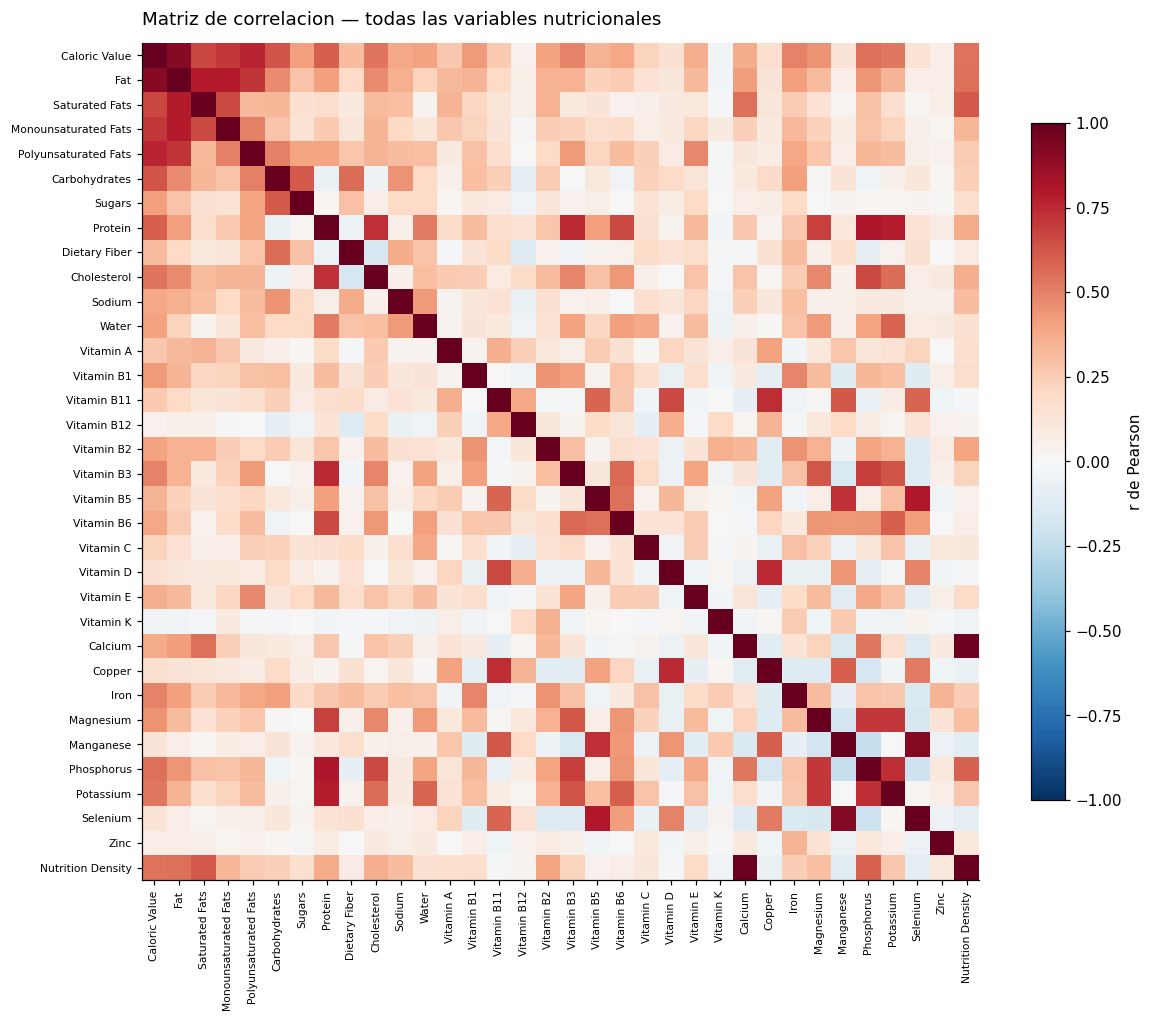

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(nutrients)), nutrients, rotation=90, fontsize=7)
ax.set_yticks(range(len(nutrients)), nutrients, fontsize=7)
ax.grid(False)
ax.set_title("Matriz de correlacion, todas las variables nutricionales", loc="left", pad=12)

cb = fig.colorbar(im, ax=ax, shrink=0.75)
cb.set_label("r de Pearson")
plt.tight_layout()

### Interpretacion de la correlacion con las calorias

**La grasa es el mayor impulsor de las calorias** (r = 0.91). Los subtipos de grasa la siguen
(poliinsaturada 0.76, monoinsaturada 0.70, saturada 0.67) porque son componentes de `Fat`
mismo, no senales independientes. Carbohidratos (0.63) y Proteina (0.60) vienen despues —
coherente con que estos tres macronutrientes son los unicos que aportan energia. Solo
`Vitamin K` es (despreciablemente) negativa con r = -0.02, es decir, sin relacion lineal.

**Dos advertencias que cambian como leer el resto de la tabla:**

1. **Las filas son por porcion, no por 100 g.** La masa de la porcion va de ~1.6 g a ~636 g
   (mediana ~132 g). El tamano de la porcion infla *todas* las variables a la vez, por eso
   `Water` muestra r = 0.41 pese a no aportar calorias: las porciones grandes simplemente
   contienen mas de todo. Buena parte de las correlaciones intermedias (potasio, hierro,
   magnesio…) reflejan el tamano de la porcion mas que una relacion nutricional real.

2. **Las calorias son casi deterministas, no solo correlacionadas.** `Caloric Value` pareciera ser practicamente una columna calculada. Un modelo que la prediga a partir de esos tres nutrientes se veria casi perfecto por razones aritmeticas, no por haber aprendido nada sobre los alimentos.

## 4. Correlacion de cada componente con `Nutrition Density`

`Nutrition Density` es el otro candidato natural a variable objetivo (un indice que resume
la "calidad nutricional" del alimento). Repetimos el mismo analisis de correlacion que
hicimos con las calorias para entender de que depende este indice.

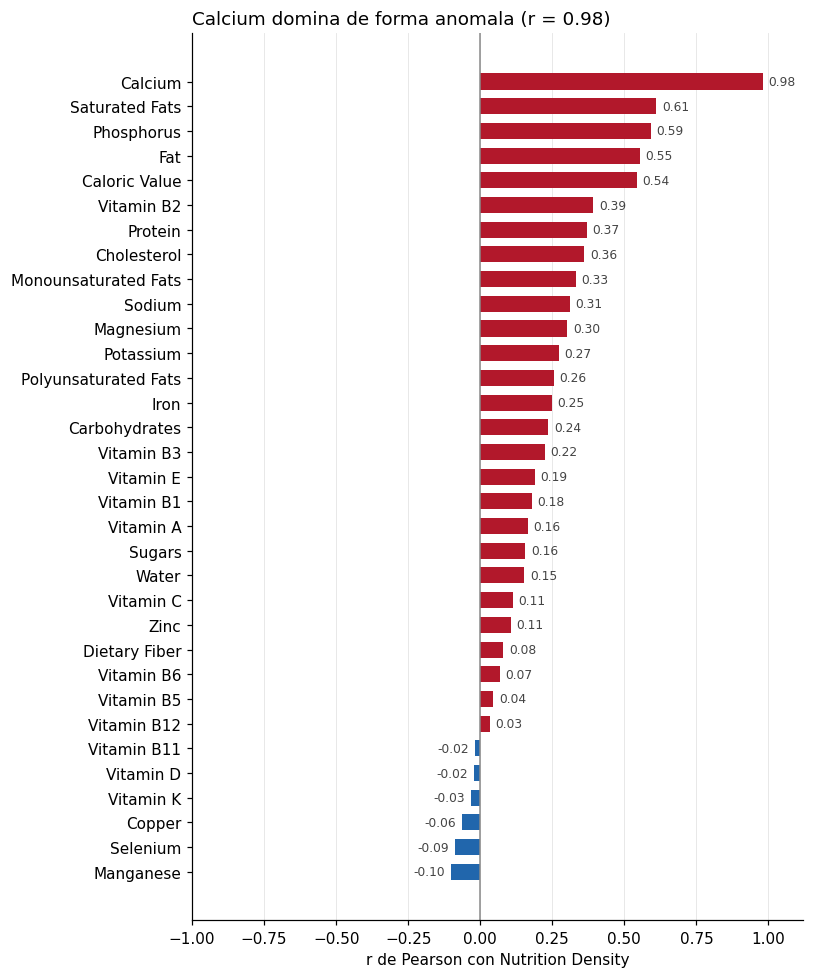

In [9]:
nd_corr = corr_matrix["Nutrition Density"].drop("Nutrition Density").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 9))
orden_nd = nd_corr.sort_values()
ax.barh(orden_nd.index, orden_nd.values,
        color=[POS if v >= 0 else NEG for v in orden_nd], height=0.65)
ax.axvline(0, color=NEUTRAL, lw=1)
ax.set_xlim(-1, 1.12)
ax.set_xlabel("r de Pearson con Nutrition Density")
ax.set_title("Calcium domina de forma anomala (r = 0.98)", loc="left")
ax.grid(axis="y", visible=False)
for name, v in orden_nd.items():
    ax.text(v + (0.02 if v >= 0 else -0.02), name, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color="#444")
plt.tight_layout()

### Interpretacion: `Nutrition Density` pareciera ser una columna calculada

La correlacion de `Nutrition Density` con `Calcium` es **0.98**. El par mas fuerte de toda
la matriz, por encima incluso de `Fat` y `Caloric Value`. Un indice de calidad nutricional
no deberia ser casi una copia exacta de un solo mineral. Es decir, no es una medicion independiente sino probablemente un valor **derivado** de los nutrientes.

**Conclusion clave para elegir el problema de ML:** los dos candidatos obvios a variable
objetivo a primera vista parecen ser columnas calculadas

Predecir cualquiera de los dos a partir de la composicion no seria "aprender" un patron,
sino re-derivar una formula que ya existe. Esto orienta la propuesta de la
seccion 6 hacia un enfoque no supervisado, que no depende de una variable objetivo.

## 5. Descripcion de cinco columnas

Se eligen cinco columnas que ilustran los distintos roles que juegan las variables en el dataset (identificador, macronutriente, mineral y los dos indices derivados):

* Caloric Value (Valor Calórico): Representa la cantidad de energía que aporta el alimento. En este conjunto de datos, el promedio es de aproximadamente 237 kcal. Presenta un rango muy amplio, desde alimentos con casi cero calorías (mínimo de 3 kcal) hasta un máximo de 1578 kcal.


* Fat (Grasas Totales): Indica la cantidad de grasa presente en el alimento. El valor promedio es de 10.7 gramos. Aunque hay alimentos que no contienen grasa (mínimo de 0), otros alcanzan concentraciones altas de hasta 87.5 gramos.


* Protein (Proteínas): Muestra el contenido proteico de cada alimento. En promedio, aportan 18.4 gramos. Es importante notar que existen alimentos sin nada de proteína (0 gramos) y otros con una gran concentración que llega a los 86.9 gramos.


* Water (Agua): Mide el nivel de humedad o contenido de agua. El promedio es de 101.6 gramos por registro, pero varía drásticamente dependiendo del tipo de alimento, alcanzando un máximo de 535.8 gramos.


* Nutrition Density (Densidad Nutricional): Es un valor calculado que resume la calidad nutritiva del alimento. Tiene un promedio de 144.6, pero muestra una variación enorme en el dataset, con puntuaciones que van desde un mínimo de 1.025 hasta un máximo de 1337.

## 6. Propuesta de un problema de Machine Learning

> Esta seccion es una **propuesta**: se define el problema y se argumentan las columnas de entrada. 

### Problema propuesto: recomendador de alimentos sustitutos usando clustering

Agrupar los alimentos por su perfil nutricional para recomendar sustitutos o evaluar nuevas opciones. El sistema funciona agrupando los alimentos en clústeres basados en la distancia matemática entre sus valores nutricionales. 
* Por ejemplo: Al ingresar un alimento nuevo al software, el modelo evalúa su composición, lo asigna al clúster correspondiente y recupera a sus "vecinos más cercanos". A partir de ahí, se pueden aplicar reglas o filtros para sugerir alternativas (ej. recomendar un alimento del mismo clúster nutricional, pero filtrando por el que tenga menor porcentaje de grasa).

### Por que este enfoque y no uno supervisado

El analisis de las secciones 3 y 4 muestra que los dos objetivos supervisados obvios
(`Caloric Value` y `Nutrition Density`) seguramente son **columnas calculadas** a partir de la composicion, asi que predecirlos seria re-derivar una formula, no aprender (*data leakage*). Un enfoque
**no supervisado** (clustering, p. ej. K-Means) evita el problema de raiz: **no hay variable
objetivo**, se agrupa por similitud de perfil. Ademas es directamente util para el negocio
(sustituir alimentos, armar menus, encontrar alternativas equivalentes).

### Que columnas se usarian como entrada, y  cuales no

Al no haber variable objetivo, **no aplica excluir columnas realmente**. La decision de
columnas sería:

- Se usan todas las columnas de información nutricional como entrada. Juntas *definen* el perfil que hace que dos alimentos sean "parecidos". Quitar nutrientes limitaría la nocion de similitud. Para agrupar las variables numéricas son útiles.
- **Se pueden omitir las dos columnas-resumen** (`Nutrition Density` y `Caloric Value`). No causan leakage, pero seguramente se deriban de las demas (seccion 4), asi que técnicamente **duplican** informacion ya presente y sobre-pesarian esas dimensiones en el calculo de distancias. 
- **`food` no es una entrada**, es el identificador que se devuelve como resultado (el
  alimento recomendado).

### Preprocesamiento que requeriria la propuesta

Dos puntos que se desprenden del EDA y que serian necesarios antes de agrupar:

1. **Estandarizar las variables** (z-score). Las escalas van de decimas (vitaminas) a miles
   (`Potassium`). Sin estandarizar, unas pocas columnas dominarian la distancia.
2. **Normalizar cada fila por porcion** (p. ej. a 100 kcal o 100 g). Como las filas son por porcion (seccion 3), sin normalizar el clustering agruparia por *tamano de porcion* en vez de por *perfil nutricional*, que es justo lo que necesitaríamos para agrupar adecuadamente